In [1]:
import numpy as np

x, y = np.loadtxt(r'C:\Users\Gebruiker\Desktop\my_data.txt', unpack=True)
print("Array x:", x)
print("Array y:", y)

Array x: [ 1.  9.  7.  6. 45. 65. 14. 69. 43.  9.]
Array y: [ 6.  4.  3.  1. 52. 75. 64. 69. 45. 42.]


In [6]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(a)
print(b)

[1 2 3]
[4 5 6]


In [15]:
import numpy as np

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print(np.concatenate((a, b)))
print(np.concatenate((a, b), axis=0))
print(np.concatenate((a, b), axis=1))

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


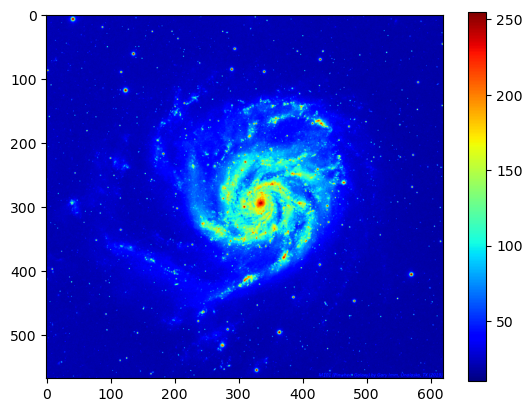

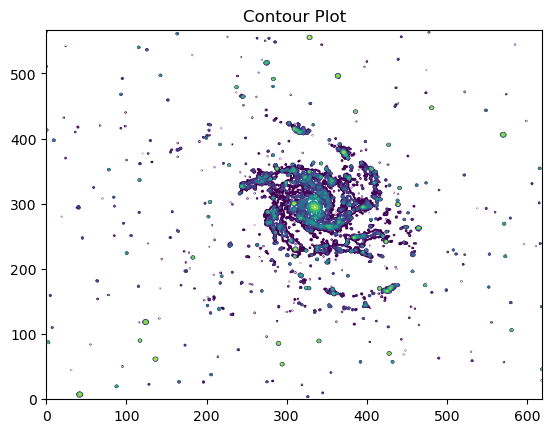

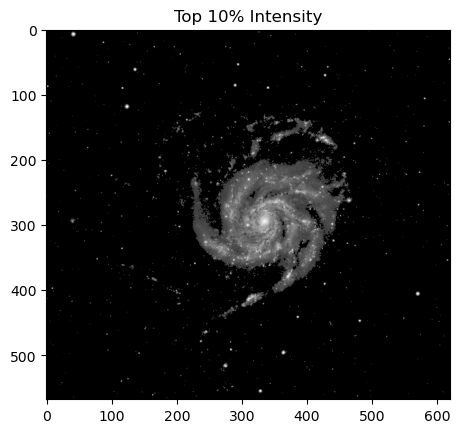

In [23]:
import imageio.v2 as imageio  
import matplotlib.pyplot as plt
import numpy as np

img = imageio.imread(r'C:\Users\Gebruiker\Desktop\m101BW.jpg')

plt.imshow(img, cmap='jet')

# Add a colorbar so you can see what numbers the colors represent (optional, but helpful!)
plt.colorbar()

# Actually display the plot on your screen
plt.show()
# Open a new blank window
plt.figure() 

# Define specific brightness levels to draw lines for (ignoring 0-99)
my_levels = [100, 125, 150, 175, 200, 225, 250]

# Draw the contour plot using those levels
plt.contour(img, levels=my_levels)

# Add a title and show it!
plt.title("Contour Plot")
plt.show()
# Open a third window
plt.figure()

# 1. Find the brightness value that separates the bottom 90% from the top 10%
threshold = np.percentile(img, 90)

# 2. Make a clean copy of your image so you don't ruin the original data
filtered_img = np.copy(img)

# 3. The Magic Step: Set any pixel darker than the threshold to 0 (black)
filtered_img[filtered_img < threshold] = 0

# 4. Plot the new, highly filtered image
plt.imshow(filtered_img, cmap='gray') 
plt.title("Top 10% Intensity")
plt.show()

In [2]:
import numpy as np

# Load the file into a single variable without trying to unpack it
data = np.loadtxt(r'C:\Users\Gebruiker\Desktop\ngc6946.txt')

# Print the shape of the data and the first 5 numbers
print("Shape of data:", data.shape)
print("First 5 numbers:", data[:5])


Shape of data: (140000,)
First 5 numbers: [-0.00142 -0.00155 -0.001   -0.00055 -0.00086]


Max: 0.0606
Min: 0.0048
Sum: 0.8915
Mean: 0.0223
Std Dev: 0.0127


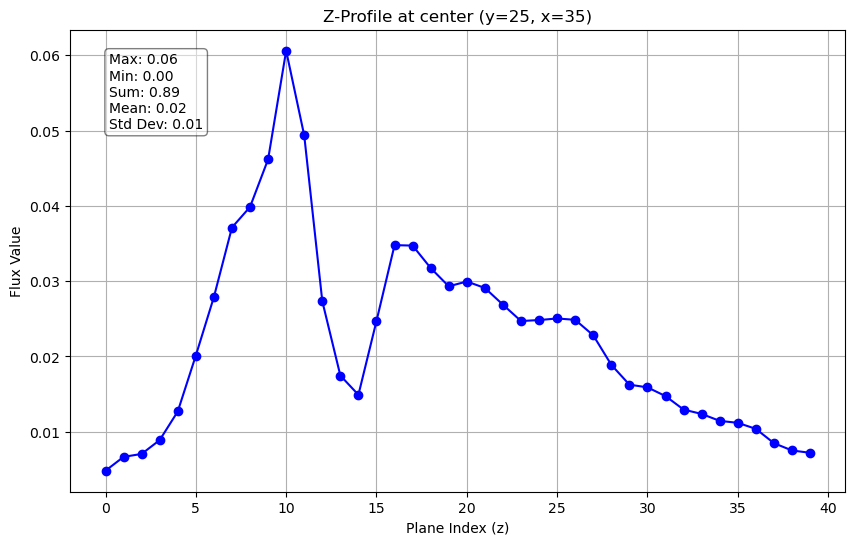

In [5]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt(r'C:\Users\Gebruiker\Desktop\ngc6946.txt')

# Reshape into the correct 3D shape: (z, y, x)
cube = data.reshape((40, 50, 70))

# Get the z-profile in the middle of the x,y plane
mid_y = 50 // 2
mid_x = 70 // 2

# This selects all 40 values along the z-axis at the center (x,y) point
z_profile = cube[:, mid_y, mid_x]

# Calculate statistics
stats = {
    "Max": np.max(z_profile),
    "Min": np.min(z_profile),
    "Sum": np.sum(z_profile),
    "Mean": np.mean(z_profile),
    "Std Dev": np.std(z_profile)
}

for key, value in stats.items():
    print(f"{key}: {value:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(z_profile, marker='o', linestyle='-', color='b')
plt.title(f"Z-Profile at center (y={mid_y}, x={mid_x})")
plt.xlabel("Plane Index (z)")
plt.ylabel("Flux Value")
stat_text = "\n".join([f"{k}: {v:.2f}" for k, v in stats.items()])
plt.text(0.05, 0.95, stat_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.grid(True)
plt.show()

Plane Mean: 0.0023
Plane Std Dev: 0.0116
Contour Levels: [np.float64(0.0023), np.float64(0.0139), np.float64(0.0254)]


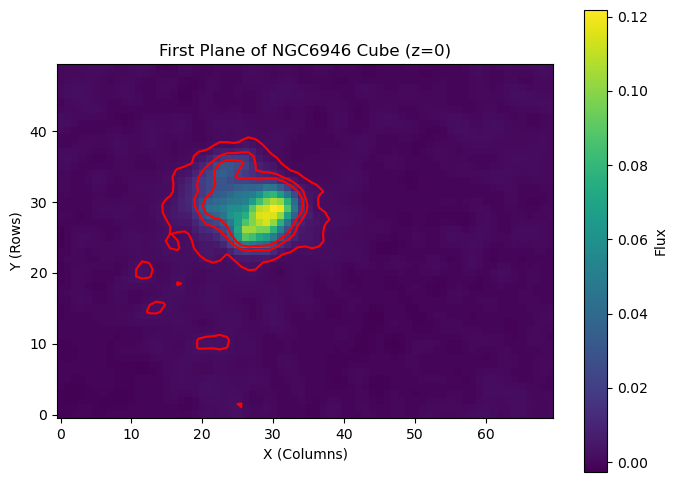

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data_flat = np.loadtxt(r'C:\Users\Gebruiker\Desktop\ngc6946.txt')

#  Reshape into (planes, rows, columns) -> (z, y, x)
cube = data_flat.reshape((40, 50, 70))

#  Extract the first plane (the image at z = 0)
first_plane = cube[0, :, :]

#  Calculate mean and standard deviation of this plane
p_mean = np.mean(first_plane)
p_std = np.std(first_plane)

#  Define contour levels:
levels = [p_mean, p_mean + p_std, p_mean + 2 * p_std]

# Plot the image
plt.figure(figsize=(8, 6))

img = plt.imshow(first_plane, origin='lower', cmap='viridis')
plt.colorbar(img, label='Flux')

#  Draw the contours
plt.contour(first_plane, levels=levels, colors='red', origin='lower')

plt.title('First Plane of NGC6946 Cube (z=0)')
plt.xlabel('X (Columns)')
plt.ylabel('Y (Rows)')

# Display statistics for verification
print(f"Plane Mean: {p_mean:.4f}")
print(f"Plane Std Dev: {p_std:.4f}")
print(f"Contour Levels: {[round(l, 4) for l in levels]}")

plt.show()

In [8]:
import scipy.constants as const

class Galaxy:
    """class for redshift calculation of galaxies"""
    
    # Class variables
    caH_0 = 3968.5  # Calcium H line in rest frame
    
    # Import the speed of light (in m/s) and make it a class variable
    c = const.c     

    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
        
    def redshift(self):
        z = (self.caH - self.caH_0) / self.caH
        return z
        
    def velocity(self):
        v_meters_per_sec = self.redshift() * self.c
        v_km_per_sec = v_meters_per_sec / 1000.0
        return v_km_per_sec

example_galaxy = Galaxy("NGC 1300", calciumHline=4050.0)

print(f"Galaxy Name: {example_galaxy.name}")
print(f"Observed Ca H-line: {example_galaxy.caH}")
print(f"Redshift (z): {example_galaxy.redshift():.5f}")
print(f"Velocity: {example_galaxy.velocity():.2f} km/s")

Galaxy Name: NGC 1300
Observed Ca H-line: 4050.0
Redshift (z): 0.02012
Velocity: 6032.86 km/s


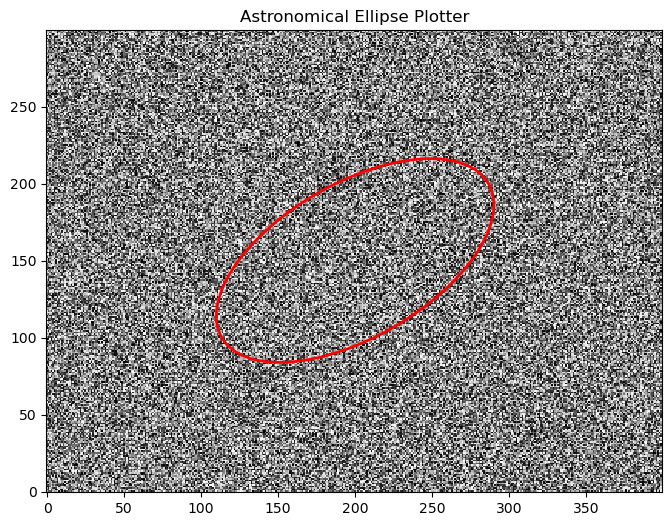

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
data = np.random.random((Ny, Nx))

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

ax.imshow(data, interpolation='none', origin='lower', cmap='gray')

center_x = Nx / 2
center_y = Ny / 2

width = 100 * 2   
height = 50 * 2   
angle = 30.0      

# Create the ellipse shape
ellipse = Ellipse(xy=(center_x, center_y), width=width, height=height, 
                  angle=angle, edgecolor='red', facecolor='none', linewidth=2)

# Add the shape to our image
ax.add_patch(ellipse)
plt.title('Astronomical Ellipse Plotter')
plt.show()